In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task - 1: Implementation of MCP Neurons:
1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two
inputs:
Hint:
• Aggregate all the inputs.
• Handcraft a Threshold values for ”AND” and ”OR” Function.
• Implement a if else statement as stated above.

In [19]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        input_sum = X1[i] + X2[i]

        if input_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T_and = 2

result_and = MCP_Neurons_AND(X1, X2, T_and)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T_and}: {result_and}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [20]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        input_sum = X1[i] + X2[i]

        if input_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T_or = 1

result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T_or}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


3.2.1 Answer the Following Question:




 You can use Text cell of your notebook to answer the question.




• Question - 1: List out all the limitations of MCP - Neurons.




Answer =


The McCulloch-Pitts (MCP) neuron was a groundbreaking first step, but it has several structural and functional limitations:


1. Fixed Weights: The model does not have learnable parameters; weights are effectively "hardcoded" (usually treated as equal) rather than being adjusted through an automated learning process.


2. Binary Inputs and Outputs Only: It can only process binary data ($x \in \{0, 1\}$ and $y \in \{0, 1\}$), making it unsuitable for continuous or real-world decimal data.



3. Handcrafted Thresholds: The threshold ($T$) must be manually determined by a human for each specific logic gate or task.



4. Linear Separability: It can only solve problems where the data can be separated by a single straight line (linear decision boundary).No Training Algorithm: Unlike the Perceptron, the MCP neuron lacks a mechanism to "learn" from errors; it is a static representation.


5. Simplified Biology: It is a highly simplified representation of a biological neuron and cannot be used to make complex conclusions about how real biological neurons function.


• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

Anser =


The XOR (Exclusive OR) function is famously non-linearly separable, meaning a single MCP neuron cannot solve it with a single threshold. However, you can solve it by combining multiple MCP neurons into a multi-layer structure.


To devise "if-else" rules for XOR, you would essentially need to combine the logic of an OR gate and a NAND gate. An XOR output is $1$ only if (Input 1 OR Input 2 is true) AND (Input 1 AND Input 2 is NOT true).




The "If-Else" Logic Strategy:


Step 1 (OR Gate): Check if $X_1 + X_2 \ge 1$.



Step 2 (NAND Gate/Inhibitory): Check if $X_1 + X_2 < 2$. (Alternatively, use an inhibitory connection that fires if both are $1$).



Final Rule: The output is $1$ only if Step 1 is true AND Step 2 is true.

In python:

In [21]:
def MCP_XOR(X1, X2):
    result = []
    for x1, x2 in zip(X1, X2):
        gate_or = 1 if (x1 + x2 >= 1) else 0
        gate_nand = 1 if (x1 + x2 < 2) else 0

        if gate_or == 1 and gate_nand == 1:
            result.append(1)
        else:
            result.append(0)
    return result

4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.

1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 0 and 1. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_0_and_1.csv





2. Load the Dataset:
Start by loading the MNIST dataset containing digits 0 and 1.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and ML/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Answers: Shape Questions

**Question 1: What does the shape of X represent?**

The shape of X is `(12665, 784)`. This means there are 12,665 samples in the dataset, and each image has 784 features. Each MNIST image is 28×28 pixels = 784 pixels, which are flattened into a single row vector.

**Question 2: What does the shape of y represent?**

The shape of y is `(12665,)`. This is a 1D array containing 12,665 labels, one for each image in X. Each value is either **0** or **1**, representing which digit the corresponding image shows.

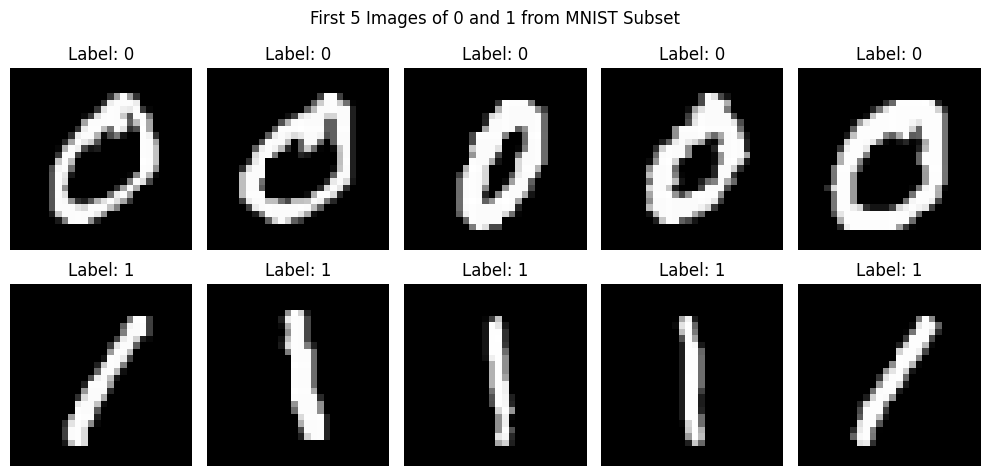

In [23]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

Step 2: Initialize Weights and Bias

In [24]:
# Initialize weights and bias to zero
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

### Answers: Weights & Bias Questions

**Question 3: What does the weights array represent in this context?**

The weights array is a 1D array of length 784 (one weight per pixel). Each weight represents the **importance or contribution of that specific pixel** to the perceptron's decision. During training, pixels that are consistently bright (or dark) for one class but not the other will have their corresponding weights pushed to larger positive or negative values.

**Question 4: Why are we initializing weights to zero? What effect could this have on the training process?**

Weights are initialized to zero as a simple, neutral starting point. Every feature starts with equal (zero) influence. For a perceptron, this is acceptable because the perceptron learning rule updates weights based on misclassifications, so the model will still learn even from a zero start. However, zero initialization can be a problem in deeper networks (e.g., it causes the "symmetry breaking" problem in neural networks where all neurons learn the same thing). For a single perceptron, it works fine in practice.

 Step 3: Implement the Decision Function (Activation Function)

In [25]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data using the step activation function.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Weight vector of shape (n_features,)
    - bias: Scalar bias term

    Returns:
    - y_pred_all: Predicted labels (0 or 1) for all input samples
    """
    predictions = np.dot(X, weights) + bias

    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

Step 4: Implement the Perceptron Learning Algorithm

In [26]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data), shape (n_samples, n_features)
    - y: True labels, shape (n_samples,)
    - weights: Initial weights, shape (n_features,)
    - bias: Initial bias (scalar)
    - learning_rate: Step size for weight updates (default 0.1)
    - epochs: Number of full passes through the dataset (default 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Final training accuracy (float between 0 and 1)
    """
    n_samples = X.shape[0]
    accuracy = 0.0

    for epoch in range(1, epochs + 1):
        correct = 0
        convergence_flag = True
        for i in range(n_samples):
            # Compute the weighted sum (net input)
            z = np.dot(X[i], weights) + bias

            # Apply step activation function
            y_hat = 1 if z >= 0 else 0

            # Update weights and bias only if prediction is wrong
            if y_hat != y[i]:
                error = y[i] - y_hat
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error
                convergence_flag = False
            else:
                correct += 1

        accuracy = correct / n_samples

        # Print progress every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.4f}")

        # Early stopping if fully converged
        if convergence_flag:
            print(f"Converged at epoch {epoch}!")
            break

    return weights, bias, accuracy

### Answers: Perceptron Algorithm Questions

**Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?**

This line computes the **net weighted input** (also called the linear combination or aggregation function) for sample i. It multiplies each pixel value by its corresponding weight, sums all 784 products together, then adds the bias. The result z represents how strongly the perceptron believes the current sample belongs to class 1. If z >= 0, it predicts class 1; otherwise class 0.

**Question 6: What happens when the prediction is wrong? How are the weights and bias updated?**

When the prediction y_hat does not match the true label y[i], the error (y[i] - y_hat) is either +1 (predicted 0 but true is 1) or -1 (predicted 1 but true is 0). The update rules are:
- `weights += learning_rate × error × X[i]` - each weight is nudged in the direction that would have produced the correct output
- `bias += learning_rate × error` - the bias is also shifted to move the decision boundary

This is the Perceptron Learning Rule: it only updates when wrong, and the magnitude of the update is controlled by the learning rate.

**Question 7: Why is the final accuracy important, and what do you expect it to be?**

The final accuracy tells us how well the perceptron has learned to separate the two classes on the training data. For 0 vs 1 classification, we expect very high accuracy (close to 1.0 / 100%) because the digits 0 and 1 are visually very distinct — they are nearly linearly separable in pixel space. The Perceptron Convergence Theorem guarantees that if the data is linearly separable, the algorithm will find a perfect decision boundary.

 Step 5: Train the Perceptron

In [27]:
# Re-initialise before training (clean slate)
weights = np.zeros(X.shape[1])
bias = 0

# Train the perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100)

print("\nThe Final Training Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9992
Converged at epoch 13!

The Final Training Accuracy is:  1.0


Step 6: Visualize Misclassified Images (0 vs 1)

In [28]:
# Get predictions for all data points using final weights
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answers: Misclassification Questions

**Question 8: What does misclassified_idx store, and how is it used?**

misclassified_idx stores the **integer indices** of all samples where the perceptron's prediction y_pred did not match the true label y. It is created using np.where(y_pred != y)[0], which returns the positions (indices) in the arrays where the condition is True. These indices are then used to retrieve the corresponding images from X and display them, along with both the predicted and true labels, so we can visually inspect what the model got wrong.

**Question 9: How do you interpret the result if the output is 'All images were correctly classified!'?**

It means the perceptron achieved 100% training accuracy. It found a linear decision boundary (a hyperplane in 784-dimensional pixel space) that perfectly separates all digit-0 images from all digit-1 images. This is expected for 0 vs 1 because these two digits are highly visually distinct and their pixel distributions are nearly linearly separable. It confirms the Perceptron Convergence Theorem that is if data is linearly separable, the algorithm always converges to a perfect solution.

 Task 3: Perceptron Algorithm for 3 vs 5 Classification


Step 1: Load the 3 vs 5 Dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI and ML/mnist_3_and_5.csv")

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_35_raw = df_3_5["label"].values

# Convert labels to binary: 3 -> 0, 5 -> 1  (perceptron needs {0,1})
y_35 = np.where(y_35_raw == 5, 1, 0)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)
print("Class distribution - 3s:", np.sum(y_35 == 0), "| 5s:", np.sum(y_35 == 1))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Class distribution - 3s: 1484 | 5s: 1257


 Step 2: Visualize the 3 vs 5 Dataset

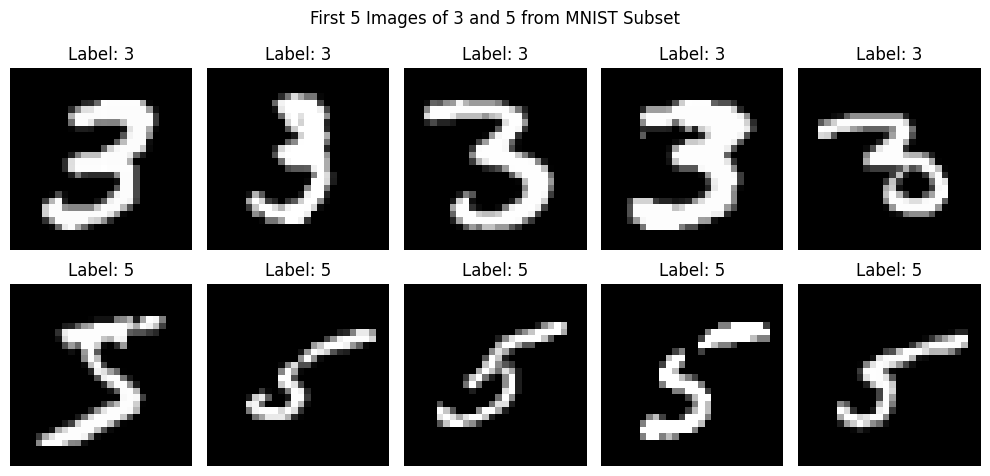

In [30]:
# Separate images by class
images_3 = X_35[y_35 == 0]
images_5 = X_35[y_35 == 1]
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

Step 3: Initialize Weights and Bias for 3 vs 5

In [31]:
# Initialize weights and bias to zero
weights_35 = np.zeros(X_35.shape[1])  # 784 weights
bias_35 = 0
learning_rate_35 = 0.1
epochs_35 = 100

print(f"Weights shape: {weights_35.shape}")
print(f"Initial bias: {bias_35}")

Weights shape: (784,)
Initial bias: 0


Step 4: Train the Perceptron on 3 vs 5

In [32]:
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35, weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)

print(f"\nFinal Training Accuracy (3 vs 5): {accuracy_35:.4f}")

Epoch 10: Accuracy = 0.9566
Epoch 20: Accuracy = 0.9661
Epoch 30: Accuracy = 0.9726
Epoch 40: Accuracy = 0.9719
Epoch 50: Accuracy = 0.9788
Epoch 60: Accuracy = 0.9759
Epoch 70: Accuracy = 0.9792
Epoch 80: Accuracy = 0.9792
Epoch 90: Accuracy = 0.9843
Epoch 100: Accuracy = 0.9858

Final Training Accuracy (3 vs 5): 0.9858


Step 5: Evaluate and Visualize Misclassified Images (3 vs 5)

Final Accuracy (3 vs 5): 0.9869
Total misclassified: 36 out of 2741 samples


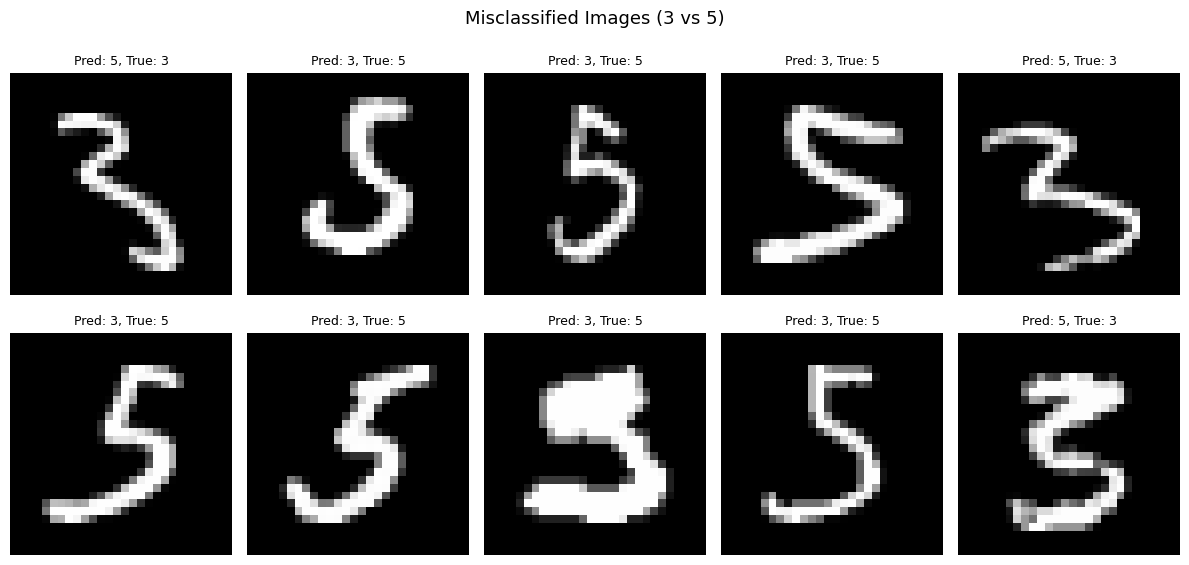

In [33]:
# Get predictions for all 3 vs 5 data
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

# Map binary predictions back to original labels for display
y_pred_35_display = np.where(y_pred_35 == 1, 5, 3)
y_true_35_display = np.where(y_35 == 1, 5, 3)

# Calculate final accuracy
final_accuracy_35 = np.mean(y_pred_35 == y_35)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")
print(f"Total misclassified: {np.sum(y_pred_35 != y_35)} out of {len(y_35)} samples")

# Visualize misclassified images
misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]

if len(misclassified_idx_35) > 0:
    n_show = min(10, len(misclassified_idx_35))
    rows = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(12, rows * 3))
    axes = axes.flat
    for ax, idx in zip(axes, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_35_display[idx]}, True: {y_true_35_display[idx]}", fontsize=9)
        ax.axis("off")
    # Turn off any empty axes
    for ax in axes:
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

**Accuracy**: The perceptron achieves noticeably lower accuracy on 3 vs 5 compared to 0 vs 1. While 0 vs 1 typically converges to ~100% accuracy, 3 vs 5 produces a non-trivial number of misclassifications.

**Why is 3 vs 5 harder?**
- Digits 3 and 5 share very similar visual structure as both have curves, similar height, and overlapping pixel activations in the middle regions.
- The pixel-level differences are subtle and vary across handwriting styles.
- The two classes are **not cleanly linearly separable** in raw 784-dimensional pixel space, which is a fundamental limitation of the perceptron.

**What do the misclassified images tell us?**
- Many misclassified images are ambiguous or poorly written digits.
- The perceptron's linear decision boundary cannot capture the complex curved relationships between pixel values that distinguish 3 from 5.

**Perceptron Limitation:**
This demonstrates the core limitation of the single-layer perceptron: it can only learn linearly separable patterns. For more complex classification problems (like 3 vs 5), we need more powerful models such as multi-layer perceptrons (MLPs) or deep neural networks that can learn non-linear decision boundaries through hidden layers and non-linear activation functions.